# 내 손으로 만드는 토큰 임베딩과 Dense Retriever

**오늘의 결과물:** 무작위 토큰 테이블을 검색 loss로 학습시키고, 직접 만든 attention encoder와 비교한다.
토큰 임베딩의 개념은 이미 안다고 가정한다. 각 셀은 `Shift+Enter`로 순서대로 실행한다.
먼저 결과를 예상한 다음 실행하고, 예상과 다르면 수식·shape·데이터를 확인한다.

CPU만 사용한다. pretrained 모델 다운로드는 없다. 이 폴더의 `.venv` Python 3.12를 커널로 선택한다.
원리 설명은 [THEORY.ko.md](THEORY.ko.md), 변경할 구현은 [lab.py](lab.py), 데이터는 [data.py](data.py)에 있다.

**범위:** BPE 규칙 학습 → 임베딩 초기화 → lookup gradient → 검색 loss → 평균 모델 → 직접 구현한 Transformer.
이 모델은 BERT의 양방향 encoder 연산 일부를 사용한다. BERT의 MLM·NSP 사전학습 전체를 재현하지 않는다.
자료는 12문서/48학습질의/24검증질의의 합성 교육셋이다. 높은 점수도 실제 한국어 검색 품질의 증거는 아니다.

In [1]:
import sys, json, math, inspect
from pathlib import Path
import torch
from torch.nn import functional as F
from IPython.display import display, Code, Image
import lab
from lab import (Config, Vocabulary, TokenTable, AttentionBlock, Retriever,
                 new_model, encode, train_experiment, evaluate, save_experiment)
from data import DOCS, DOC_NAMES, TRAIN, VALID, ORDER_PAIR, OOV_QUERY

print('Python:', sys.executable)
print('PyTorch:', torch.__version__)
torch.set_num_threads(1)
vocab = Vocabulary()
print(lab.validate_data(vocab))

Python: /home/baemo_pc/260821/dense-retrieval-lab/.venv/bin/python
PyTorch: 2.14.0+cpu
{'documents': 12, 'train_queries': 48, 'valid_queries': 24, 'vocabulary': 101}


## 1. 무엇을 구분하도록 학습할 것인가

온톨로지의 `(주체, 관계, 객체)` 관점에서 아래 두 문서를 읽어 보자.
둘은 단어 구성은 같지만 관계의 방향이 다르다. 오늘은 둘을 다른 정답으로 구분해야 한다.
다른 업무에서는 상위·하위 개념의 여러 문서가 모두 정답일 수 있으므로 label 정책이 먼저다.

`VALID`는 학습에 없는 질의 문자열이며 모든 토큰은 이미 알려져 있다.
이것은 알려진 문서에 대한 새 표현 테스트다. 새 entity나 도메인 테스트가 아니다.

In [2]:
a, b = ORDER_PAIR
print('A:', DOCS[a])
print('B:', DOCS[b])
print('같은 token multiset:', sorted(DOCS[a].split()) == sorted(DOCS[b].split()))
for q, target in TRAIN[:4]:
    print(q, '→', DOC_NAMES[target])
print('VALID 첫 두 개:', VALID[:2])

A: 고양이 가 쥐 를 쫓다
B: 쥐 가 고양이 를 쫓다
같은 token multiset: True
고양이 가 쥐 를 추격 하다 → 고양이가 쥐를 쫓음
고양이 가 쥐 를 뒤쫓다 → 고양이가 쥐를 쫓음
고양이 가 쥐 를 쫓다 설명 → 고양이가 쥐를 쫓음
고양이 가 쥐 를 추격 장면 → 고양이가 쥐를 쫓음
VALID 첫 두 개: [('고양이 가 쥐 를 뒤쫓다 장면', 0), ('고양이 가 쥐 를 추격 하다 설명', 0)]


## 2. 토크나이저를 학습해도 임베딩의 의미는 학습되지 않는다

먼저 `DOCS+TRAIN`으로 BPE vocabulary와 merge 규칙을 새로 만든다. 여기에는 PyTorch optimizer가 없다.
빈도에 따른 문자열 분할 규칙을 만드는 단계다. 각 ID의 실수 벡터는 별도로 초기화하고 loss로 학습한다.

**예상:** vocab 목표 160과 256에서 merge 수는 어떻게 다를까? 기본 문자만으로 목표 크기를 넘을 수도 있다.
실사용 한국어라면 더 큰 학습 corpus, Unicode·숫자·고유명사 처리, 길이와 OOV 평가가 필요하다.

아래 BPE는 보조 실험이다. 이후 주 실습에서는 행별 gradient를 읽기 쉽도록 공백 vocabulary를 사용한다.
BPE ID를 공백 vocabulary의 테이블에 넣으면 ID 의미가 어긋난다. tokenizer와 모델은 한 세트로 관리한다.

In [3]:
from tokenizer_lab import train_tokenizer
for size in (160, 256):
    tokenizer = train_tokenizer(vocab_size=size)
    state = json.loads(tokenizer.to_str())['model']
    print('목표/실제 vocab:', size, tokenizer.get_vocab_size(), 'merges:', len(state['merges']))
    print(tokenizer.encode(TRAIN[0][0]).tokens)
    print('OOV 예시:', tokenizer.encode(OOV_QUERY).tokens)

목표/실제 vocab: 160 206 merges: 0
['고', '양', '이</w>', '가</w>', '쥐</w>', '를</w>', '추', '격</w>', '하', '다</w>']
OOV 예시: ['패', '[UNK]', '[UNK]', '드</w>', '리', '[UNK]', '버', '리</w>']
목표/실제 vocab: 256 256 merges: 50
['고양이</w>', '가</w>', '쥐</w>', '를</w>', '추격</w>', '하다</w>']
OOV 예시: ['패', '[UNK]', '[UNK]', '드</w>', '리', '[UNK]', '버', '리</w>']


## 3. E를 실제 파라미터로 만들고 ID를 조회한다

어휘 크기 $V=101$, 토큰 차원 $d=48$로 $E\in\mathbb{R}^{V\times d}$를 만든다.
표준편차 0.1의 정규분포에서 초기화하고 PAD 행만 0으로 둔다.
이 값은 실습 선택이며 최적화된 보편적 설정이 아니다.

`E[ids]`는 one-hot 행렬 $O$와 $E$의 곱 $OE$와 같다. ID는 이산 인덱스이며 gradient는 테이블 값으로 간다.
vocabulary는 `DOCS+TRAIN`만으로 정해져 있고 `VALID`로 확장하지 않는다.

In [4]:
torch.manual_seed(42)
E = TokenTable(len(vocab), 48)
ids, mask = vocab.batch([TRAIN[0][0], DOCS[0]])
x = E(ids)
display(Code(inspect.getsource(TokenTable), language='python'))
print('E:', tuple(E.weight.shape), 'IDs:', tuple(ids.shape), 'lookup:', tuple(x.shape))
print('첫 질의 IDs:', ids[0].tolist())
one_hot = F.one_hot(ids, num_classes=len(vocab)).float()
torch.testing.assert_close(x, one_hot @ E.weight)
print('lookup == one_hot @ E 확인')

class TokenTable(nn.Module):
    """nn.Embedding의 중심: 학습 가능한 V x D 행렬과 ID에 따른 행 조회."""

    def __init__(self, vocab_size, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(vocab_size, dim))
        nn.init.normal_(self.weight, mean=0.0, std=0.1)
        with torch.no_grad():
            self.weight[0].zero_()

    def forward(self, ids):
        # one_hot(ids) @ E와 같은 조회. padding_idx는 PAD의 조회 gradient를 막는다.
        return F.embedding(ids, self.weight, padding_idx=0)

E: (101, 48) IDs: (2, 6) lookup: (2, 6, 48)
첫 질의 IDs: [15, 3, 82, 32, 91, 96]


lookup == one_hot @ E 확인


## 4. 같은 토큰이 두 번 나오면 어느 행에 gradient가 쌓일까?

검색보다 먼저 아주 작은 연산에서 검증하자. ID가 `[2, 2, 5]`이고 조회한 값의 합을 loss로 두면,
행 2의 각 좌표에는 gradient 2, 행 5에는 1이 생긴다. 다른 행은 0이다.
이 임의 loss는 의미를 학습시키기 위한 목적이 아니라 역전파 경로를 분리하는 실험이다.

**직접 수정:** 아래 `ids`에 5를 하나 더 넣으면 어느 값이 달라질지 예상하고 실행한다.

In [5]:
table = torch.randn(7, 4, requires_grad=True)
ids = torch.tensor([2, 2, 5])
loss = table[ids].sum()
loss.backward()
print(table.grad)
print(lab.lookup_demo()['explanation'])

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [2., 2., 2., 2.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [1., 1., 1., 1.],
        [0., 0., 0., 0.]])
E[2]는 2회 조회되어 각 좌표의 gradient가 2, E[5]는 1입니다.


## 5. 검색 목적함수를 만든다

질의와 문서를 같은 encoder로 독립 인코딩하고 L2 정규화한다.

$$s_{ij}=z(q_i)^Tz(d_j),\qquad L=-\frac1B\sum_i\log\frac{\exp(s_{i,y_i}/\tau)}{\sum_j\exp(s_{ij}/\tau)}$$

여기서는 12개 문서를 모두 후보로 사용한다. 질의마다 정답은 하나이며 나머지는 negative다.
같은 문서를 답으로 갖는 여러 질의를 서로 negative로 취급하지 않는다.
문서 표현을 detach하지 않으므로 질의와 문서 양쪽에서 E까지 gradient가 흐른다.

한 질의에서 $\partial L/\partial s_j=(p_j-y_j)/\tau$.
`tau`는 softmax 분포와 미분 배율을 모두 바꾼다.
벡터 정규화의 gradient까지 유도하려면 THEORY의 6절을 읽는다.

In [6]:
initial = new_model(vocab, Config(model='mean'))
query, label = TRAIN[0]
q = encode(initial, vocab, [query])        # [1, 32]
d = encode(initial, vocab, DOCS)           # [12, 32]
scores = q @ d.T                          # [1, 12]
scores.retain_grad()
tau = 0.1
loss = F.cross_entropy(scores / tau, torch.tensor([label]))
loss.backward()
p = (scores.detach() / tau).softmax(dim=-1)
expected = p.clone()
expected[0, label] -= 1
expected /= tau
torch.testing.assert_close(scores.grad, expected)
print('loss:', loss.item())
print('probabilities:', p[0].tolist())
print('dL/dscores:', scores.grad[0].tolist())
print('추격 행 gradient norm:', initial.tokens.weight.grad[vocab.ids['추격']].norm().item())
print('문서에만 있는 쫓다 행 gradient norm:', initial.tokens.weight.grad[vocab.ids['쫓다']].norm().item())

loss: 1.1376198530197144
probabilities: [0.3205811381340027, 0.3205811381340027, 0.0049752588383853436, 0.0049752588383853436, 0.1517174392938614, 0.1517174392938614, 2.9676881240447983e-05, 0.0002901960979215801, 0.007011170964688063, 4.335398261900991e-05, 0.0009812986245378852, 0.037096716463565826]
dL/dscores: [-6.794188499450684, 3.2058112621307373, 0.04975258186459541, 0.04975258186459541, 1.517174482345581, 1.517174482345581, 0.000296768790576607, 0.0029019606299698353, 0.0701117217540741, 0.00043353979708626866, 0.009812984615564346, 0.37096723914146423]
추격 행 gradient norm: 3.048841714859009
문서에만 있는 쫓다 행 gradient norm: 3.154141426086426


## 6. autograd를 수치 미분과 대조한다

테이블의 한 좌표를 $+\epsilon$, $-\epsilon$ 바꿔 loss 차이로 gradient를 근사한다.
자동 미분과 일치하면 lookup부터 score까지 이어지는 실제 경로를 확인한 것이다.
정밀도 영향을 줄이려고 이 진단은 float64, $\epsilon=10^{-6}$을 사용한다.
별도 모델 복사본에서 SGD 한 번을 수행하므로 다음 본 학습의 초기값은 바뀌지 않는다.

In [7]:
probe = lab.gradient_probe(new_model(vocab, Config(model='transformer')), vocab)
display(probe)
assert probe['pad_gradient_norm'] == 0
assert probe['unused_gradient_norm'] == 0
assert probe['probe_update_norm'] > 0

{'query': '고양이 가 쥐 를 추격 하다',
 'target': '고양이가 쥐를 쫓음',
 'loss': 1.0710439149045612,
 'diagnostic_unfreezes_tokens': False,
 'probe_token': '추격',
 'probe_gradient_norm': 1.6863669943054937,
 'probe_update_norm': 0.01686366994305493,
 'pad_gradient_norm': 0.0,
 'unused_gradient_norm': 0.0,
 'analytic_gradient': -0.8455014592243402,
 'finite_difference': -0.8455014597341659,
 'coordinate': ['고양이', 21],
 'largest_row_gradients': [['고양이', 2.3543197753846137],
  ['쫓다', 2.1773957779285333],
  ['쥐', 2.0227933153686024],
  ['하다', 1.789344826751175],
  ['추격', 1.6863669943054937],
  ['가', 1.1937187575274477],
  ['를', 1.0843407392545523],
  ['교사', 0.8907146070477563]]}

## 7. 모델 내부를 읽는다: Q·K·V와 masking까지

토큰 차원 48 → 4 heads(각 12차원) → 두 attention block → masked mean → 선형 32차원 → L2 정규화.
입력에는 학습 가능한 위치 표현과 LayerNorm이 있다. block은 Post-LN과 GELU FFN을 쓴다.
`mask[:, None, None, :]`가 key 축을 가리는 이유, padding을 pooling에서도 제외하는 이유를 설명해 보자.

아래는 라이브러리의 pretrained encoder가 아니라 이번에 작성한 실제 구현이다.
평균 모델은 수학적으로 같은 bag에 부동소수점 순서 오차도 생기지 않게 합산 순서만 정렬한다.

In [8]:
display(Code(inspect.getsource(AttentionBlock), language='python'))
display(Code(inspect.getsource(Retriever), language='python'))

class AttentionBlock(nn.Module):
    """양방향 multi-head attention + Post-LN + FFN. BERT 전체 재현은 아니다."""

    def __init__(self, dim, heads):
        super().__init__()
        if dim % heads:
            raise ValueError("dim은 heads의 배수여야 합니다.")
        self.heads = heads
        self.qkv = nn.Linear(dim, 3 * dim)
        self.out = nn.Linear(dim, dim)
        self.norm1 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, 4 * dim), nn.GELU(), nn.Linear(4 * dim, dim))
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x, mask):
        batch, length, dim = x.shape
        qkv = self.qkv(x).reshape(batch, length, 3, self.heads, dim // self.heads)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)
        logits = q @ k.transpose(-2, -1) / math.sqrt(dim // self.heads)
        # key 방향의 PAD를 가린다. causal mask는 없으므로 양쪽 문맥을 본다.
        logits = logits.masked_fill(~mask[:, None, None, :], float("-inf"))
        attention = logits.softmax(dim=-1)
        values = (attention @ v).transpose(1, 2).contiguous().reshape(batch, length, dim)
        x = self.norm1(x + self.out(values))
        x = self.norm2(x + self.ffn(x))
        return x, attention

class Retriever(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        if config.model not in {"mean", "transformer"}:
            raise ValueError("model은 mean 또는 transformer여야 합니다.")
        self.config = config
        self.tokens = TokenTable(vocab_size, config.dim)
        self.tokens.weight.requires_grad_(not config.freeze_tokens)
        if config.model == "transformer":
            self.position = nn.Embedding(config.max_length, config.dim)
            nn.init.normal_(self.position.weight, std=0.1)
            self.input_norm = nn.LayerNorm(config.dim)
            self.blocks = nn.ModuleList([
                AttentionBlock(config.dim, config.heads) for _ in range(config.layers)
            ])
        self.projection = nn.Linear(config.dim, config.output_dim, bias=False)

    def forward(self, ids, mask, *, use_positions=True, trace=False):
        x = self.tokens(ids)
        raw = x
        attentions = []
        if self.config.model == "transformer":
            if use_positions:
                positions = torch.arange(ids.shape[1], device=ids.device)
                x = x + self.position(positions)[None, :, :]
            x = self.input_norm(x)
            for block in self.blocks:
                x, attention = block(x, mask)
                if trace:
                    attentions.append(attention)
        # PAD query 위치에도 값은 생기지만 pooling에서는 제외한다.
        pool_x, pool_mask = x, mask
        if self.config.model == "mean":
            # 덧셈의 부동소수점 오차까지 동일하게: 같은 multiset은 같은 순서로 더한다.
            # 의미/위치 정보를 추가하는 연산이 아니며 mean의 수학적 결과는 같다.
            order = ids.argsort(dim=1, stable=True)
            pool_x = x.gather(1, order.unsqueeze(-1).expand_as(x))
            pool_mask = mask.gather(1, order)
        float_mask = pool_mask.unsqueeze(-1).to(x.dtype)
        pooled = (pool_x * float_mask).sum(1) / float_mask.sum(1).clamp_min(1)
        vector = F.normalize(self.projection(pooled), p=2, dim=-1)
        if trace:
            return vector, {"lookup": raw, "contextual": x, "pooled": pooled,
                            "attention": attentions}
        return vector

## 8. 먼저 평균 모델을 학습시킨다

학습 loop는 `zero_grad → encode(q) → encode(d) → scores → cross_entropy → backward → step`이다.
이때 E도 optimizer에 등록된 파라미터이므로 함께 갱신된다. Adam의 weight decay는 0이다.
입력에 없던 `[UNUSED]` 행과 PAD가 그대로인지도 검사한다.

**예상:** 같은 토큰으로 역할을 뒤집은 세 쌍을 이 구조로 구분할 수 있을까?
그 여섯 문서에는 학습 질의의 절반이 연결된다. 쌍을 구분 못 하면 그 절반에서 최선의 정답 확률도 1/2이다.
따라서 이 데이터의 평균 loss 이론상 하한은 $0.5\log 2\approx0.34657$ 이상이고,
균형 검증 질의의 결정적 동점 처리에서 Recall@1 상한은 75%다.
정규화 점수와 유한한 온도로 나머지 후보 확률도 정확히 0은 아니므로 loss는 하한보다 약간 높을 수 있다.

In [9]:
display(Code(inspect.getsource(train_experiment), language='python'))
mean_model, mean_result = train_experiment(Config(model='mean'), vocab)
save_experiment(mean_model, vocab, mean_result)
print('before:', mean_result['before'])
print('after: ', mean_result['after'])
print('이론상 loss 하한:', 0.5 * math.log(2))
print('관측 마지막 loss:', mean_result['loss'][-1])
print('테이블 총 변화량:', mean_result['token_table_change_norm'])

def train_experiment(config, vocab=None, verbose=True):
    if config.steps < 1 or config.temperature <= 0:
        raise ValueError("steps와 temperature는 양수여야 합니다.")
    vocab = vocab or Vocabulary()
    validate_data(vocab)
    model = new_model(vocab, config)
    token_before = model.tokens.weight.detach().clone()
    before, before_rows = evaluate(model, vocab, VALID)
    probe = gradient_probe(model, vocab)
    queries = vocab.batch([q for q, _ in TRAIN], config.max_length)
    documents = vocab.batch(DOCS, config.max_length)
    labels = torch.tensor([label for _, label in TRAIN])
    # weight_decay=0: 현재 실습에서는 미등장 임베딩 행의 변화 원인을 없앤다.
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=0)
    history = []
    model.train()
    for step in range(1, config.steps + 1):
        optimizer.zero_grad(set_to_none=True)
        q = model(*queries)
        d = model(*documents)
        # 전체 12개 문서가 후보. 같은 label의 여러 query가 서로 negative가 되지 않는다.
        scores = q @ d.T / config.temperature
        loss = F.cross_entropy(scores, labels)
        loss.backward()
        optimizer.step()
        history.append(float(loss.detach()))
        if verbose and (step == 1 or step % 50 == 0 or step == config.steps):
            print(f"[{config.model}] step={step:3d} train_loss={loss.item():.5f}")
    after, after_rows = evaluate(model, vocab, VALID)
    train_metrics, _ = evaluate(model, vocab, TRAIN)
    checks = invariants(model, vocab)
    unchanged = (model.tokens.weight.detach() - token_before).norm().item()
    if config.freeze_tokens:
        assert unchanged == 0
    else:
        assert unchanged > 0
    torch.testing.assert_close(model.tokens.weight[0], token_before[0], atol=0, rtol=0)
    torch.testing.assert_close(model.tokens.weight[2], token_before[2], atol=0, rtol=0)
    result = {"config": asdict(config), "before": before, "after": after,
              "train": train_metrics, "loss": history, "gradient_probe": probe,
              "checks": checks, "token_table_change_norm": unchanged,
              "before_rankings": before_rows, "after_rankings": after_rows}
    return model, result

[mean] step=  1 train_loss=1.67357
[mean] step= 50 train_loss=0.34761
[mean] step=100 train_loss=0.34719
[mean] step=150 train_loss=0.34704


[mean] step=200 train_loss=0.34695
[mean] step=250 train_loss=0.34690
[mean] step=300 train_loss=0.34686
before: {'recall@1': 0.4166666567325592, 'recall@3': 0.75, 'mrr': 0.6156249642372131}
after:  {'recall@1': 0.75, 'recall@3': 1.0, 'mrr': 0.875}
이론상 loss 하한: 0.34657359027997264
관측 마지막 loss: 0.3468610346317291
테이블 총 변화량: 2.2289109230041504


## 9. 위치와 문맥을 결합하는 Transformer를 학습시킨다

동일 데이터, 같은 차원과 loss로 비교한다. 구조와 파라미터 수는 달라지므로 위치만의 단일요인 비교는 아니다.
seed와 300 steps를 고정한다. 검증 점수로 early stopping하지 않는다.
이후 검증 결과를 보고 설정을 고르면 별도 test set 없이는 일반화 주장을 할 수 없다.

[transformer] step=  1 train_loss=1.85366


[transformer] step= 50 train_loss=0.00255


[transformer] step=100 train_loss=0.00115


[transformer] step=150 train_loss=0.00094


[transformer] step=200 train_loss=0.00083


[transformer] step=250 train_loss=0.00073


[transformer] step=300 train_loss=0.00063
before: {'recall@1': 0.4166666567325592, 'recall@3': 0.6666666865348816, 'mrr': 0.599355161190033}
after:  {'recall@1': 1.0, 'recall@3': 1.0, 'mrr': 1.0}
구조 확인: {'padding_difference': 5.029141902923584e-08, 'order_pair_vector_distance': 1.3962111473083496, 'without_positions_distance': 1.1572057445619066e-07, 'note': '위치 제거는 구조의 순서 불변성을 확인하며, 별도 재학습 성능 비교는 아닙니다.'}


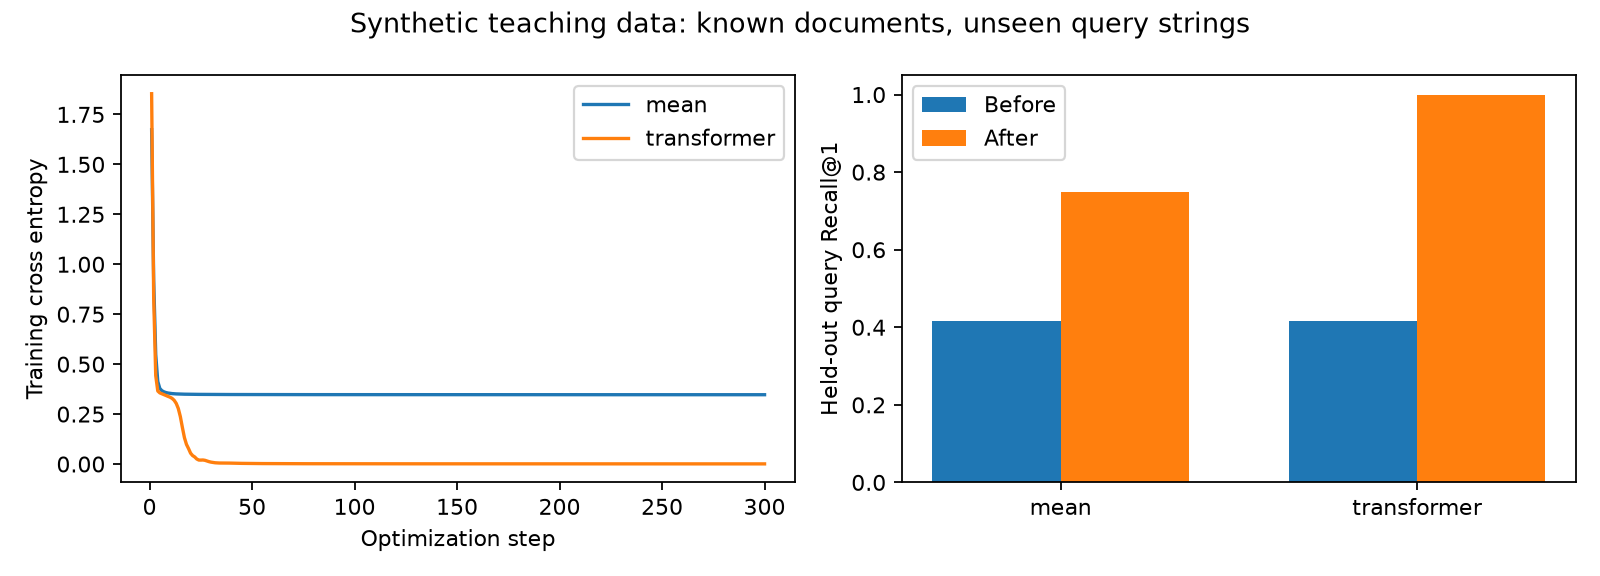

In [10]:
context_model, context_result = train_experiment(Config(model='transformer'), vocab)
save_experiment(context_model, vocab, context_result)
print('before:', context_result['before'])
print('after: ', context_result['after'])
print('구조 확인:', context_result['checks'])
results = {'mean': mean_result, 'transformer': context_result}
lab.plot_results(results)
display(Image(filename=str(lab.ARTIFACTS / 'learning.png')))

## 10. E의 같은 행에서 출발해 서로 다른 문맥 출력이 생기는지 확인한다

아래 두 문서에서 `고양이`는 같은 ID다. lookup 값은 정확히 같다.
문장 내 위치와 다른 토큰과의 상호작용 이후에는 다른 hidden state를 갖는다.
attention weight만으로 정답의 인과적 이유를 단정하지는 않는다.

**예상:** 학습된 Transformer에서 위치 정보만 제거하면 역할 역전 두 문서의 mean pooled 벡터는 어떻게 될까?
이 조작은 구조의 순서 불변성 진단이다. 위치 없이 따로 학습한 모델의 성능 실험은 아니다.

In [11]:
pair = [DOCS[a], DOCS[b]]
ids, mask = vocab.batch(pair)
with torch.no_grad():
    z, trace = context_model(ids, mask, trace=True)
    idx_a, idx_b = pair[0].split().index('고양이'), pair[1].split().index('고양이')
    raw_gap = (trace['lookup'][0, idx_a] - trace['lookup'][1, idx_b]).norm().item()
    contextual_gap = (trace['contextual'][0, idx_a] - trace['contextual'][1, idx_b]).norm().item()
    no_position = context_model(ids, mask, use_positions=False)
print('같은 토큰 lookup 차이:', raw_gap)
print('문맥 출력 차이:', contextual_gap)
print('문서 벡터 차이:', (z[0] - z[1]).norm().item())
print('위치 제거 후 문서 벡터 차이:', (no_position[0] - no_position[1]).norm().item())
print('attention shape [batch, heads, query positions, key positions]:', trace['attention'][0].shape)

같은 토큰 lookup 차이: 0.0
문맥 출력 차이: 8.920536994934082
문서 벡터 차이: 1.3962111473083496
위치 제거 후 문서 벡터 차이: 1.1572057445619066e-07
attention shape [batch, heads, query positions, key positions]: torch.Size([2, 4, 5, 5])


## 11. 저장한 모델로 직접 검색한다

질의를 바꿔 실행한다. 이 tokenizer에서는 학습 데이터처럼 조사도 띄어 써야 한다.
그 아래 OOV 실험을 보고, 검색 결과가 나온다는 사실과 모델이 입력 의미를 이해했다는 사실을 구분하자.
cosine 점수는 정답 확률이 아니다. 작은 전체 corpus에서 항상 1위는 반환된다.

In [12]:
my_query = '쥐 가 고양이 를 뒤쫓다 장면'
hits = lab.search(my_query)
print()
print('OOV 진단:')
unknown_hits = lab.search(OOV_QUERY)

+0.9886  쥐가 고양이를 쫓음  |  쥐 가 고양이 를 쫓다
+0.0631  환불 입금 소요 기간  |  환불 처리 이후 입금 소요 기간
+0.0338  제자가 교사를 가르침  |  제자 가 교사 를 가르치다

OOV 진단:
[UNK] 처리된 토큰: ['패스워드', '리커버리'] — 교육용 공백 tokenizer의 한계입니다.
+0.7770  토끼가 개를 도움  |  토끼 가 개 를 돕다
+0.4762  반려묘 먹이 선택  |  반려묘 사료 선택 안내
+0.2301  교사가 제자를 가르침  |  교사 가 제자 를 가르치다


## 12. 설계 실험: E를 동결해도 모델이 학습될까?

나머지 encoder가 있으므로 E를 고정해도 학습될 수 있다. E의 모든 행에 해석 가능한 의미를 직접 부여해야만 검색되는 것은 아니다.
다음은 같은 seed에서 E만 동결한 실험이다. E 변화량이 정확히 0인지 확인한다.
`gradient_probe`는 미분 진단을 위해 복제본의 동결을 해제하므로 그 값은 실제 동결 학습의 gradient가 아니다.
여기서는 `token_table_change_norm`을 본다. 외부 검증 없이 동결이 일반적으로 더 낫다/나쁘다고 결론내리지 않는다.

In [13]:
frozen_model, frozen_result = train_experiment(Config(model='transformer', freeze_tokens=True), vocab)
save_experiment(frozen_model, vocab, frozen_result, tag='transformer_frozen')
print('학습된 E:', context_result['after'])
print('동결된 E:', frozen_result['after'])
print('동결된 테이블 변화량:', frozen_result['token_table_change_norm'])
assert frozen_result['token_table_change_norm'] == 0

[transformer] step=  1 train_loss=1.85366


[transformer] step= 50 train_loss=0.00304


[transformer] step=100 train_loss=0.00142


[transformer] step=150 train_loss=0.00099


[transformer] step=200 train_loss=0.00078


[transformer] step=250 train_loss=0.00069


[transformer] step=300 train_loss=0.00064
학습된 E: {'recall@1': 1.0, 'recall@3': 1.0, 'mrr': 1.0}
동결된 E: {'recall@1': 1.0, 'recall@3': 1.0, 'mrr': 1.0}
동결된 테이블 변화량: 0.0


## 다음 변경은 하나씩

1. **온도:** `Config(temperature=0.5)`로 새 모델을 학습하고 loss·검증 순위를 비교한다. loss 절대값은 목적함수가 달라 단순 비교하지 않는다.
2. **새 entity:** data.py에 훈련에 없는 주체/객체를 가진 독립 test set을 추가한다. tokenizer OOV와 모델 일반화 실패를 분리한다.
3. **온톨로지 다중 정답:** 상위 타입 질의에 하위 entity 문서 둘을 모두 정답으로 지정한다. 현재 단일 label CE와 Recall 정의를 그대로 쓰면 안 된다. THEORY 7절부터 설계한다.

마지막으로 아래 세 문장에 직접 답한다.

- lookup에선 문맥을 보지 않는데 왜 `추격`의 E가 검색 학습으로 바뀌는가?
- 평균 모델의 loss가 약 0.3466에서 멈춘 것은 optimizer 실패인가, 표현 구조의 한계인가?
- 토큰화에 의해 두 entity가 같은 `[UNK]`가 됐을 때 attention을 더 깊게 하면 원래 표기를 복원할 수 있는가?

참고: [BERT 원논문](https://aclanthology.org/N19-1423/), [DPR 원논문](https://aclanthology.org/2020.emnlp-main.550/),
[PyTorch Embedding](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html),
[Hugging Face Tokenizers](https://huggingface.co/docs/tokenizers/main/en/quicktour).